In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


# Proceso de Hawkes aplicado al grupo *Voluntarios DANA Valencia*

Replicación del modelo del artículo **Masuda, Takaguchi, Sato & Yano (2012),
*Self-exciting point process modeling of conversation event sequences*** (arXiv:1205.5109),
aplicado a las secuencias de mensajes del grupo de Telegram, **canal por canal**.

## ¿Qué es el proceso de Hawkes?

Es un **proceso puntual auto-excitado**: cada evento (mensaje) aumenta
temporalmente la probabilidad de que ocurran nuevos eventos. La intensidad
(tasa instantánea de eventos) en el instante $t$ es

$$\lambda(t)=\nu+\sum_{t_i<t}\phi(t-t_i),\qquad \phi(t)=\alpha\,e^{-\beta t}\quad(t\ge 0)$$

con tres parámetros, todos en unidades de **eventos por hora** (la unidad de tiempo
que usa el paper):

| Parámetro | Significado |
|---|---|
| $\nu$ | **tasa base** (mensajes espontáneos, no provocados por otros) |
| $\alpha$ | **salto** de auto-excitación que produce cada mensaje |
| $\beta$ | **velocidad de decaimiento** de esa excitación (memoria del proceso) |

Cantidades derivadas que interpretamos:

- **Tamaño de cluster / branching ratio** $\;c=\alpha/\beta=\int_0^\infty\phi(t)\,dt$:
  nº medio de mensajes que dispara directamente un mensaje. Si $c<1$ el proceso es estable.
- **Tasa estacionaria** $\;\lambda=\dfrac{\nu}{1-\alpha/\beta}$ y tiempo medio entre eventos $\langle\tau\rangle=1/\lambda$.

## Estructura del notebook
1. Carga de datos y selección de canales.
2. Preprocesado: tiempos de evento en horas y **división en días válidos** (≥40 eventos/día),
   reiniciando el primer evento de cada día como disparador — exactamente como el paper (Apéndice 2).
3. Estimación por **máxima verosimilitud** con las ecuaciones del paper (log-verosimilitud sumada sobre los días).
4. Comprobación cruzada con la librería `Hawkes` (paquete de Omi que instalaste).
5. Estadísticos de los tiempos entre eventos (CV y correlación, ecs. 6–7 del paper).
6. Bondad de ajuste (test KS por cambio de tiempo aleatorio) y comparación entre canales.


## 0. Librerías

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Compatibilidad: el paquete Hawkes usa np.NaN, eliminado en NumPy 2.0.
# Este shim lo restaura sin afectar a nada más.
if not hasattr(np, "NaN"):
    np.NaN = np.nan

# Librería de Hawkes que instalaste (pip install hawkes). El paquete se importa
# como 'Hawkes' (con mayúscula). Lo usamos en la sección 4 como comprobación cruzada.
try:
    import Hawkes as hk
    HK_OK = True
except Exception as e:
    HK_OK = False
    print("Aviso: no se pudo importar el paquete 'Hawkes' ->", e)

plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(0)

## 1. Carga de datos

Cargamos el dataset, convertimos `date` a `datetime` y ordenamos cronológicamente.
La ruta es relativa: el notebook vive en `TFM/TFM/Hawkes/`, así que el dataset está
en `../../Datasets/`.

In [2]:
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Total de mensajes : {len(df)}")
print(f"Rango temporal    : {df['date'].min()}  ->  {df['date'].max()}")
df.head(3)

Total de mensajes : 18064
Rango temporal    : 2024-10-30 12:39:24+00:00  ->  2025-11-10 11:06:47+00:00


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False


## 2. Selección de canales

Igual que en tu análisis temporal, trabajamos con los canales (`topic_name`)
con suficiente volumen. El paper exige secuencias largas para que la estimación
sea fiable, así que nos quedamos con los canales con **más de 1000 mensajes**.

In [3]:
MIN_MENSAJES_CANAL = 1000

conteo = df["topic_name"].value_counts()
canales = conteo[conteo > MIN_MENSAJES_CANAL].index.tolist()

print("Canales seleccionados (>1000 mensajes):\n")
for c in canales:
    print(f"  {conteo[c]:>6}  |  {c}")

Canales seleccionados (>1000 mensajes):

    2856  |  Bienvenid@s a la Red de Voluntari@s (leed primero)
    2770  |  Investigación Ciudadana: Responsabilidades Políticas
    2076  |  Transporte de personas a Comunidad Valenciana
    1964  |  Asistencia Informática/Soporte EAT
    1307  |  Logística Interna Valencia(puntos de recepción)
    1170  |  Material Video/Fotográfico
    1163  |  Asistencia a Voluntarios (Comida y Acogida))
    1052  |  Grupos de Acción Voluntarios en Terreno
    1033  |  Asistencia animales compañia y otros


## 3. Preprocesado: tiempos de evento y días válidos

Tres pasos por canal, siguiendo el Apéndice 2 del paper:

1. **Unidad de tiempo = horas.** El paper fija la unidad en 1 hora (la resolución del dato
   es de minutos/segundos, demasiado fina para la estimación ML).
2. **División por días.** Cada día natural es una realización independiente del proceso
   que comparte los mismos parámetros $(\nu,\alpha,\beta)$.
3. **Días válidos.** Solo usamos los días con **≥ 40 eventos**. Dentro de cada día,
   el primer mensaje se toma como instante 0 (evento disparador), de modo que los tiempos
   de evento del día son $0=t_1\le t_2\le\dots\le t_{N_d}$ en horas.

In [4]:
MIN_EVENTOS_DIA = 40   # umbral del paper para un "día válido"

def dias_validos_horas(df_canal, min_eventos=MIN_EVENTOS_DIA):
    '''Devuelve una lista de arrays. Cada array son los tiempos de evento (en horas,
    empezando en 0) de un día con al menos `min_eventos` mensajes.'''
    d = df_canal.sort_values("date").copy()
    d["dia"] = d["date"].dt.date
    secuencias = []
    for _, g in d.groupby("dia"):
        if len(g) >= min_eventos:
            t = g["date"].values.astype("datetime64[s]").astype(np.int64)  # segundos epoch
            t = (t - t[0]) / 3600.0          # horas desde el primer evento del día
            t = np.sort(t.astype(float))
            secuencias.append(t)
    return secuencias

# Construimos las secuencias de días válidos por canal
secuencias_por_canal = {c: dias_validos_horas(df[df["topic_name"] == c]) for c in canales}

print(f"{'Canal':<55} {'días válidos':>12} {'eventos usados':>15}")
for c in canales:
    seqs = secuencias_por_canal[c]
    n_ev = sum(len(s) for s in seqs)
    print(f"{c[:53]:<55} {len(seqs):>12} {n_ev:>15}")

Canal                                                   días válidos  eventos usados
Bienvenid@s a la Red de Voluntari@s (leed primero)                11            2588
Investigación Ciudadana: Responsabilidades Políticas              15            2330
Transporte de personas a Comunidad Valenciana                      9            1543
Asistencia Informática/Soporte EAT                                 6            1847
Logística Interna Valencia(puntos de recepción)                   10             828
Material Video/Fotográfico                                         8             609
Asistencia a Voluntarios (Comida y Acogida))                       9            1056
Grupos de Acción Voluntarios en Terreno                           10             936
Asistencia animales compañia y otros                               8             663


## 4. Estimación por máxima verosimilitud (ecuaciones del paper)

La log-verosimilitud de una secuencia $0=t_1\le\dots\le t_N$ con kernel exponencial
es (ec. 24 del paper, con el primer evento como disparador):

$$\log L=-\nu\,t_N+\frac{\alpha}{\beta}\sum_{i=1}^{N}\!\left(e^{-\beta(t_N-t_i)}-1\right)
+\sum_{i=2}^{N}\log\!\big(\nu+\alpha\,A(i)\big),\qquad
A(i)=\sum_{1\le j<i}e^{-\beta(t_i-t_j)}.$$

$A(i)$ se calcula en $O(N)$ con la recursión $A(i)=e^{-\beta(t_i-t_{i-1})}\,(A(i-1)+1)$, $A(1)=0$.
La log-verosimilitud total de un canal es la **suma sobre todos sus días válidos**.

Maximizamos con un optimizador robusto (`scipy`) en lugar del descenso de gradiente
manual del paper — la verosimilitud es la misma. Para respetar las restricciones
$\nu,\alpha,\beta>0$ y $\alpha<\beta$ (estabilidad), reparametrizamos:
$\nu=e^{\theta_1}$, $\beta=e^{\theta_2}$ y $c=\alpha/\beta=\sigma(\theta_3)\in(0,1)$, con $\alpha=c\,\beta$.

In [5]:
def loglik_dia(t, nu, alpha, beta):
    '''Log-verosimilitud de Hawkes (kernel exp) para un día. t empieza en 0.'''
    N = len(t)
    if N < 2:
        return 0.0
    tN = t[-1]
    term1 = -nu * tN
    term2 = (alpha / beta) * np.sum(np.expm1(-beta * (tN - t)))   # expm1 = e^x - 1 (estable)
    # término de la suma de log con A(i) recursivo
    A = 0.0
    s = 0.0
    dt = np.diff(t)
    for k in range(N - 1):                # k corresponde al evento i = k+2 (i>=2)
        A = np.exp(-beta * dt[k]) * (A + 1.0)
        s += np.log(nu + alpha * A)
    return term1 + term2 + s

def neg_loglik_total(theta, secuencias):
    nu = np.exp(theta[0])
    beta = np.exp(theta[1])
    c = 1.0 / (1.0 + np.exp(-theta[2]))   # branching ratio en (0,1)
    alpha = c * beta
    ll = 0.0
    for t in secuencias:
        ll += loglik_dia(t, nu, alpha, beta)
    return -ll

def ajustar_hawkes(secuencias):
    '''Estima (nu, alpha, beta) por ML sobre los días válidos de un canal.'''
    # Inicialización razonable a partir de los datos (en horas)
    todos = np.concatenate([np.diff(t) for t in secuencias if len(t) > 1])
    tasa0 = 1.0 / np.mean(todos) if len(todos) else 1.0
    theta0 = np.array([np.log(tasa0 * 0.5), np.log(max(tasa0, 1.0)), 0.0])
    res = minimize(neg_loglik_total, theta0, args=(secuencias,),
                   method="Nelder-Mead",
                   options={"maxiter": 5000, "xatol": 1e-6, "fatol": 1e-6})
    nu = np.exp(res.x[0]); beta = np.exp(res.x[1])
    c = 1.0 / (1.0 + np.exp(-res.x[2])); alpha = c * beta
    return {
        "nu": nu, "alpha": alpha, "beta": beta,
        "cluster_c": alpha / beta,                 # = c, branching ratio
        "tasa_estacionaria": nu / (1.0 - alpha / beta),
        "logL": -res.fun, "convergio": res.success,
    }

resultados = {c: ajustar_hawkes(secuencias_por_canal[c]) for c in canales}

tabla = pd.DataFrame(resultados).T
tabla = tabla.rename(columns={
    "nu": "ν (base, /h)", "alpha": "α (salto, /h)", "beta": "β (decay, /h)",
    "cluster_c": "c=α/β (cluster)", "tasa_estacionaria": "λ estac. (/h)", "logL": "log L"})
tabla.index.name = "Canal"
tabla.round(4)

,"ν (base, /h)","α (salto, /h)","β (decay, /h)",c=α/β (cluster),λ estac. (/h),log L,convergio
Canal,,,,,,,
Bienvenid@s a la Red de Voluntari@s (leed primero),2.271338,9.718431,12.074291,0.804886,11.641099,4909.469826,True
Investigación Ciudadana: Responsabilidades Políticas,1.684086,12.798288,16.04574,0.797613,8.321111,4453.156618,True
Transporte de personas a Comunidad Valenciana,2.370433,15.942909,22.279819,0.715576,8.334161,3559.494505,True
Asistencia Informática/Soporte EAT,1.493696,14.056478,15.645775,0.89842,14.704635,5045.127606,True
Logística Interna Valencia(puntos de recepción),1.701444,13.382321,23.085378,0.579688,4.048052,772.520747,True
Material Video/Fotográfico,1.742435,58.187278,101.423619,0.573705,4.087396,1123.17903,True
Asistencia a Voluntarios (Comida y Acogida)),2.360072,16.138068,27.788287,0.580751,5.629281,1270.460385,True
Grupos de Acción Voluntarios en Terreno,1.96283,22.038779,38.057807,0.579087,4.663268,1220.85584,True
Asistencia animales compañia y otros,2.130819,50.314909,112.972192,0.445374,3.841904,961.512616,True


### Lectura de la tabla

- **c = α/β (cluster / branching ratio):** cuanto más cerca de 1, más "explosivo" y a ráfagas
  es el canal (cada mensaje arrastra muchos otros). Valores bajos → conversación más espontánea.
- **β (decay):** β alto = la excitación se apaga rápido (ráfagas cortas); β bajo = memoria larga.
- **ν (tasa base):** actividad de fondo independiente de la auto-excitación.
- **λ estacionaria:** tasa media de mensajes que predice el modelo (mensajes/hora).

El resultado central del paper es que **estos parámetros dependen fuertemente de cada individuo**;
aquí lo trasladamos a que **dependen del canal**.

## 5. Comprobación cruzada con la librería `Hawkes` (paquete de Omi)

El paquete que instalaste ajusta una **única secuencia continua** (no separa por días).
Lo usamos como contraste independiente y por sus diagnósticos. Equivalencia de parámetros:

- `mu` del paquete = $\nu$ del paper.
- `beta` del paquete = $\beta$ del paper.
- `alpha` del paquete = **branching ratio** $c=\alpha_\text{paper}/\beta$ (el paquete normaliza el kernel
  como $\phi(t)=\texttt{alpha}\cdot\texttt{beta}\,e^{-\texttt{beta}\,t}$), de modo que
  $\alpha_\text{paper}=\texttt{alpha}\cdot\texttt{beta}$.

Como el paquete no reinicia por días, sus valores no tienen por qué coincidir exactamente con la
sección 4, pero deberían quedar en el mismo orden de magnitud (sobre todo el branching ratio).

In [6]:
def serie_continua_horas(df_canal):
    '''Tiempos de evento (horas) de todo el canal desde su primer mensaje, sin separar días.'''
    t = df_canal.sort_values("date")["date"].values.astype("datetime64[s]").astype(np.int64)
    t = (t - t[0]) / 3600.0
    return np.sort(t.astype(float))

filas = []
modelos_hk = {}
if HK_OK:
    for c in canales:
        T = serie_continua_horas(df[df["topic_name"] == c])
        itv = [0.0, float(T[-1]) + 1e-6]
        m = hk.estimator().set_kernel("exp").set_baseline("const")
        m.fit(T, itv)
        modelos_hk[c] = m
        p = m.parameter
        filas.append({
            "Canal": c,
            "mu (=ν)": p["mu"],
            "alpha (=c)": p["alpha"],
            "beta (=β)": p["beta"],
            "α_paper=alpha·beta": p["alpha"] * p["beta"],
            "branching": m.branching_ratio(),
        })
    tabla_hk = pd.DataFrame(filas).set_index("Canal")
    display(tabla_hk.round(4))
else:
    print("Paquete Hawkes no disponible; se omite la comprobación cruzada.")

,mu (=ν),alpha (=c),beta (=β),α_paper=alpha·beta,branching
Canal,,,,,
Bienvenid@s a la Red de Voluntari@s (leed primero),0.0169,0.9469,3.1140,2.9486,0.9469
Investigación Ciudadana: Responsabilidades Políticas,0.1978,0.8671,7.8857,6.8380,0.8671
Transporte de personas a Comunidad Valenciana,0.0250,0.9161,3.1782,2.9115,0.9161
Asistencia Informática/Soporte EAT,0.0085,0.9639,5.0610,4.8785,0.9639
Logística Interna Valencia(puntos de recepción),0.0177,0.8849,2.0717,1.8334,0.8849
Material Video/Fotográfico,0.0258,0.8061,4.0366,3.2538,0.8061
Asistencia a Voluntarios (Comida y Acogida)),0.1686,0.8928,5.2780,4.7122,0.8928
Grupos de Acción Voluntarios en Terreno,0.0074,0.9380,2.7218,2.5530,0.9380
Asistencia animales compañia y otros,0.0295,0.8720,2.6327,2.2958,0.8720


In [7]:
# Comparación directa del branching ratio: paper (días válidos) vs paquete (serie continua)
if HK_OK:
    comp = pd.DataFrame({
        "c (paper, días válidos)": {c: resultados[c]["cluster_c"] for c in canales},
        "branching (paquete, continuo)": {c: modelos_hk[c].branching_ratio() for c in canales},
    })
    display(comp.round(4))

,"c (paper, días válidos)","branching (paquete, continuo)"
Bienvenid@s a la Red de Voluntari@s (leed primero),0.8049,0.9469
Investigación Ciudadana: Responsabilidades Políticas,0.7976,0.8671
Transporte de personas a Comunidad Valenciana,0.7156,0.9161
Asistencia Informática/Soporte EAT,0.8984,0.9639
Logística Interna Valencia(puntos de recepción),0.5797,0.8849
Material Video/Fotográfico,0.5737,0.8061
Asistencia a Voluntarios (Comida y Acogida)),0.5808,0.8928
Grupos de Acción Voluntarios en Terreno,0.5791,0.9380
Asistencia animales compañia y otros,0.4454,0.8720


## 6. Estadísticos de los tiempos entre eventos (IET)

El paper caracteriza las secuencias con dos estadísticos de los tiempos entre eventos
$\tau_i=t_{i+1}-t_i$:

- **Coeficiente de variación** $\mathrm{CV}=\dfrac{\sigma_\tau}{\langle\tau\rangle}$ (ec. 6).
  CV = 1 ⇒ proceso de Poisson; CV > 1 ⇒ comportamiento a ráfagas (*bursty*), típico de lo humano.
- **Correlación de IET** entre intervalos consecutivos (ec. 7). Positiva ⇒ un intervalo largo
  (corto) tiende a ir seguido de otro largo (corto).

Los calculamos sobre los IET dentro de cada día válido (coherente con el ajuste).

In [8]:
def estadisticos_iet(secuencias):
    iets = np.concatenate([np.diff(t) for t in secuencias if len(t) > 1])
    iets = iets[iets > 0]
    if len(iets) < 3:
        return np.nan, np.nan, np.nan
    cv = iets.std() / iets.mean()
    # correlación de Pearson entre IET consecutivos (ec. 7)
    corr = np.corrcoef(iets[:-1], iets[1:])[0, 1]
    return iets.mean(), cv, corr

filas = []
for c in canales:
    media, cv, corr = estadisticos_iet(secuencias_por_canal[c])
    filas.append({"Canal": c, "IET medio (h)": media, "CV": cv, "Corr. IET": corr})
tabla_iet = pd.DataFrame(filas).set_index("Canal")
print("CV>1 indica ráfagas; corr>0 indica correlación temporal positiva.\n")
tabla_iet.round(4)

CV>1 indica ráfagas; corr>0 indica correlación temporal positiva.



,IET medio (h),CV,Corr. IET
Canal,,,
Bienvenid@s a la Red de Voluntari@s (leed primero),0.0902,3.1209,0.1127
Investigación Ciudadana: Responsabilidades Políticas,0.1250,3.1717,0.1402
Transporte de personas a Comunidad Valenciana,0.1263,2.6095,0.1851
Asistencia Informática/Soporte EAT,0.0700,4.5469,0.1900
Logística Interna Valencia(puntos de recepción),0.2583,2.4498,0.0532
Material Video/Fotográfico,0.3018,2.9099,0.0873
Asistencia a Voluntarios (Comida y Acogida)),0.1835,2.6540,0.1062
Grupos de Acción Voluntarios en Terreno,0.2321,2.5194,0.0833
Asistencia animales compañia y otros,0.3168,2.1913,0.0793


## 7. Bondad de ajuste (test KS por cambio de tiempo aleatorio)

Si el modelo es correcto, al "reescalar" el tiempo con la intensidad integrada
$\Lambda(t)=\int_0^t\lambda(s)\,ds$ los eventos transformados deben ser un proceso de Poisson
de tasa 1, es decir, sus intervalos deben seguir una **exponencial(1)**. El paquete `Hawkes`
hace exactamente este test con `plot_KS` (cuanto más pegados a la diagonal, mejor el ajuste).
También mostramos `plot_N`, el nº acumulado de eventos observado frente al esperado por el modelo.

findfont: Font family 'Arial' not found.


Bienvenid@s a la Red de Voluntari@s (leed primero)


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


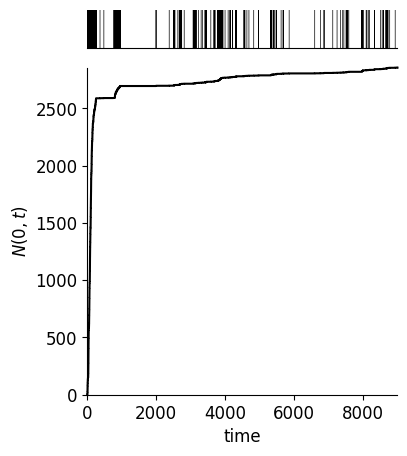

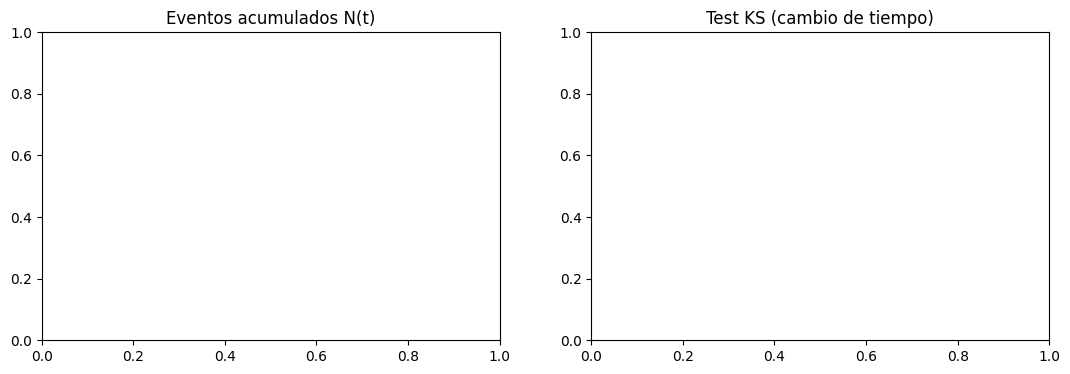

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


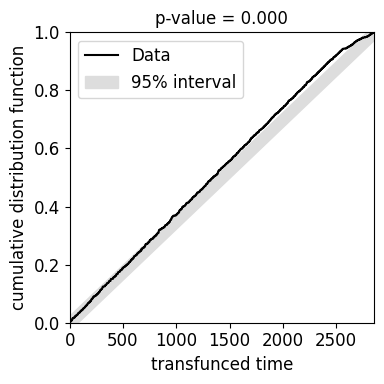

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Investigación Ciudadana: Responsabilidades Políticas


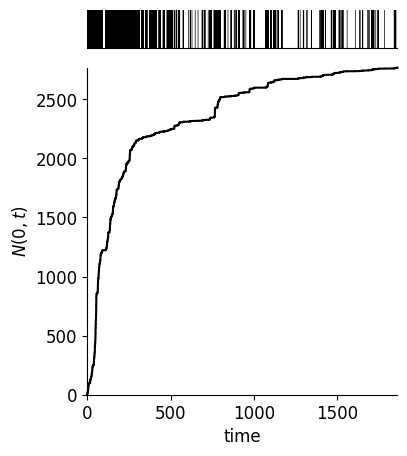

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


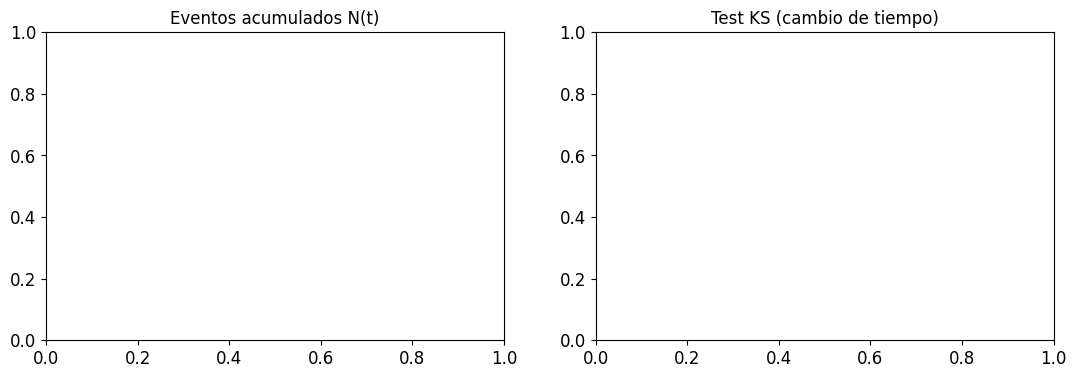

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


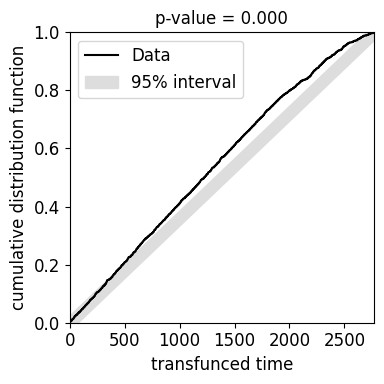

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Transporte de personas a Comunidad Valenciana


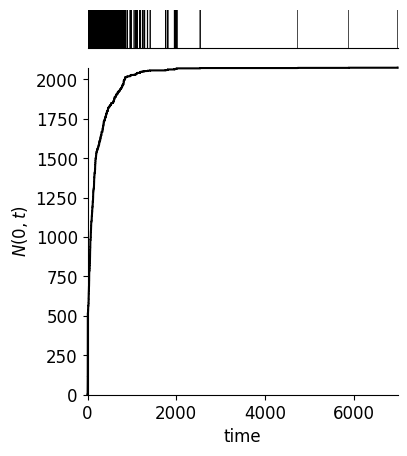

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


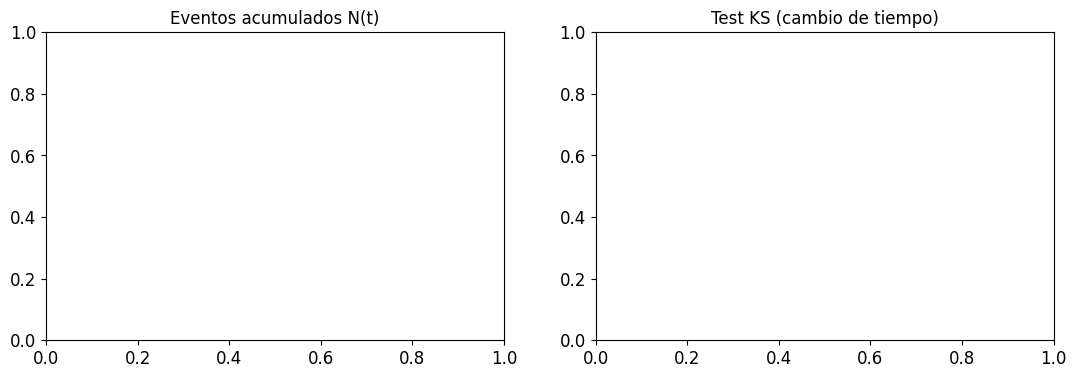

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


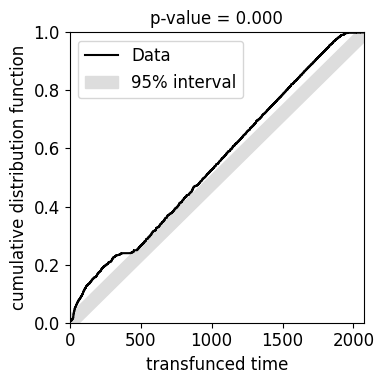

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Asistencia Informática/Soporte EAT


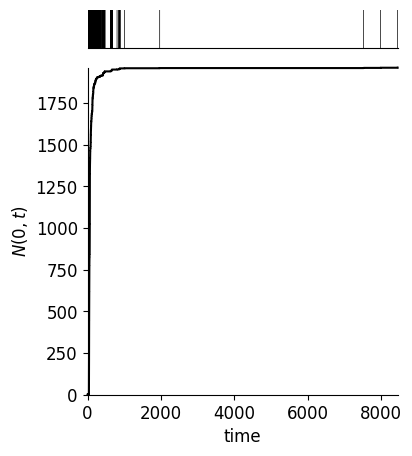

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


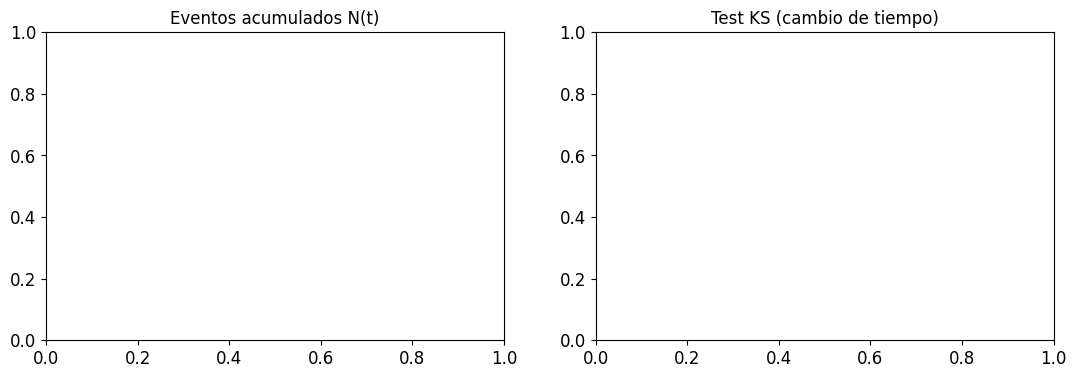

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


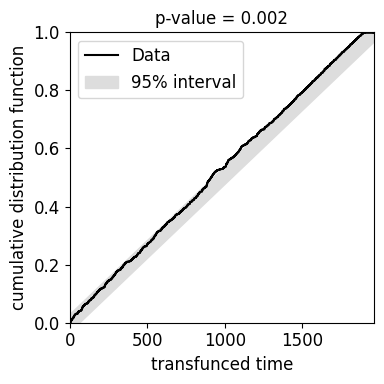

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Logística Interna Valencia(puntos de recepción)


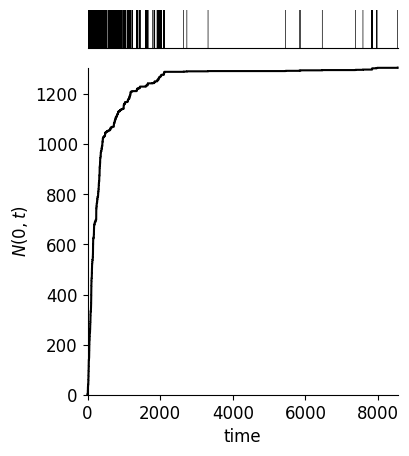

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


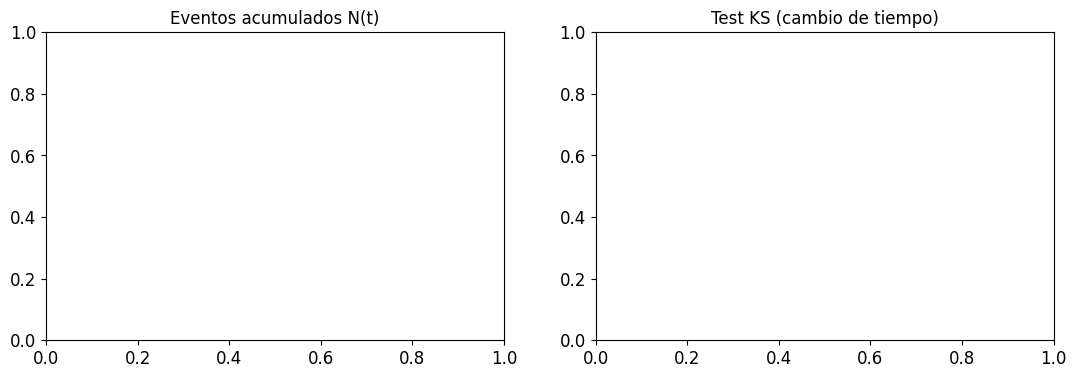

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


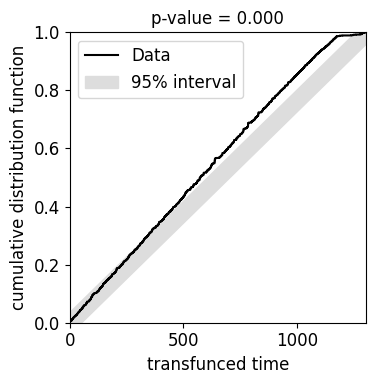

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Material Video/Fotográfico


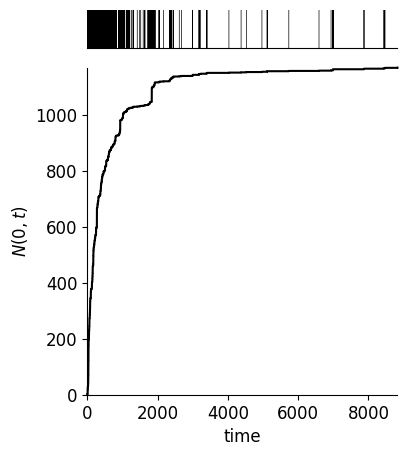

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


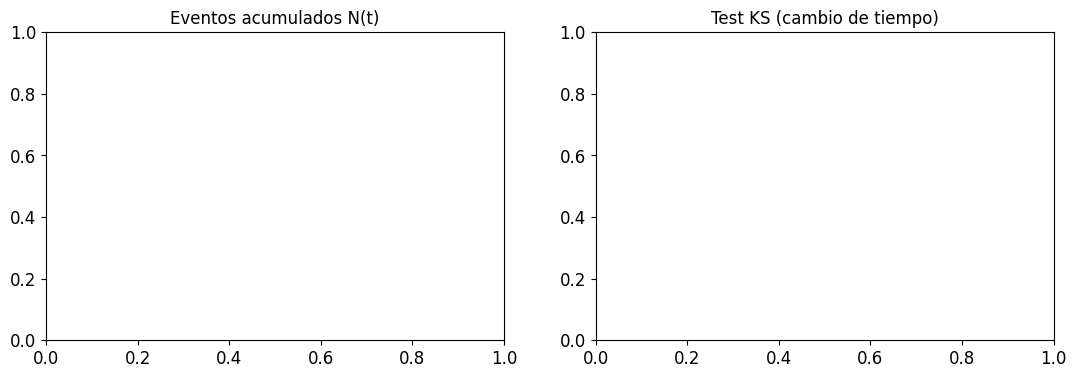

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


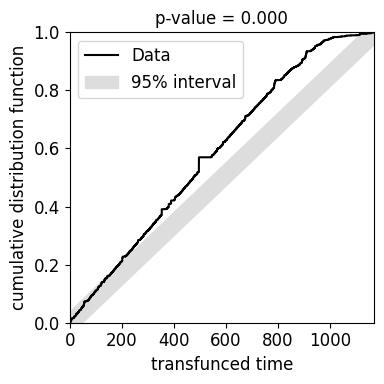

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Asistencia a Voluntarios (Comida y Acogida))


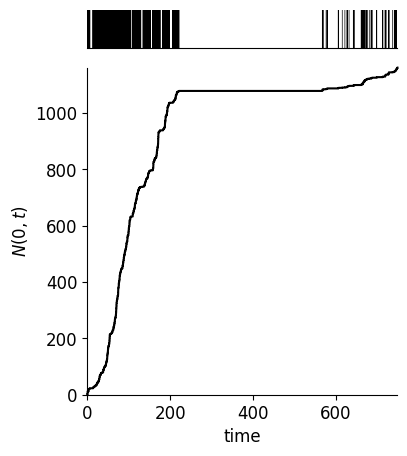

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


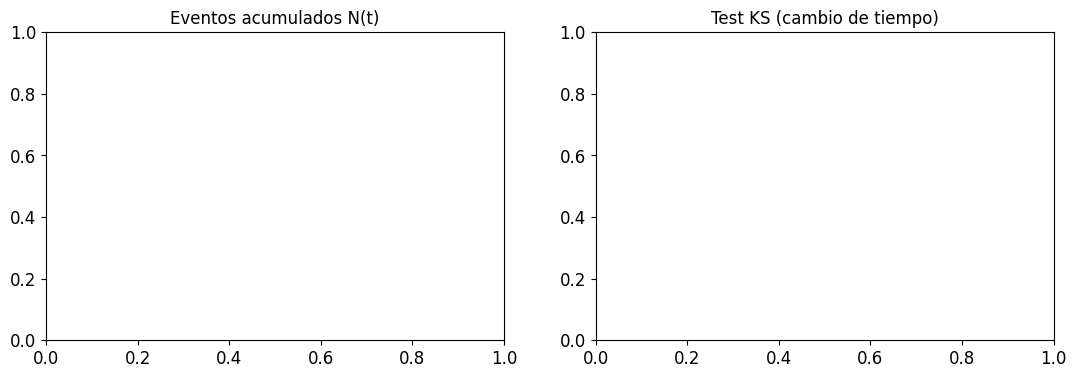

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


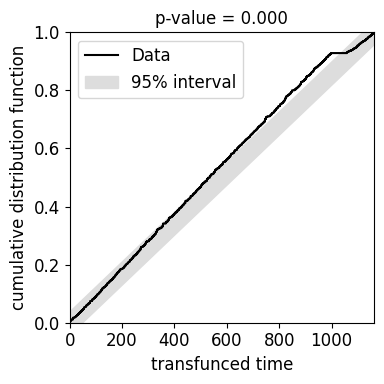

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Grupos de Acción Voluntarios en Terreno


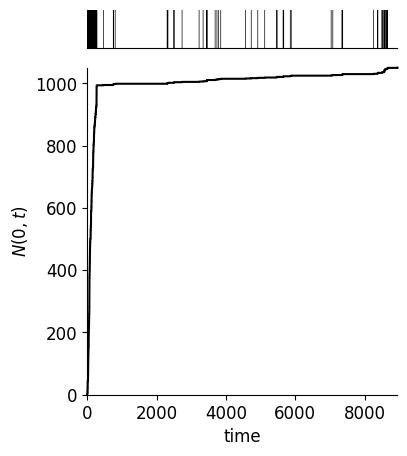

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


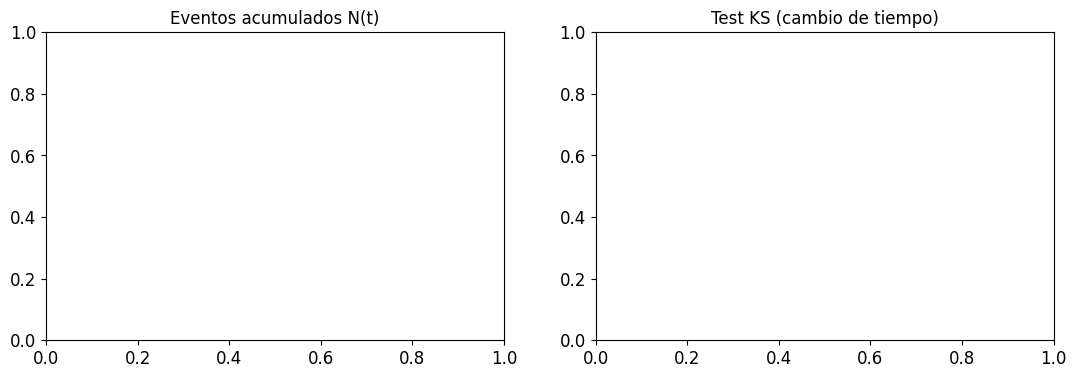

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


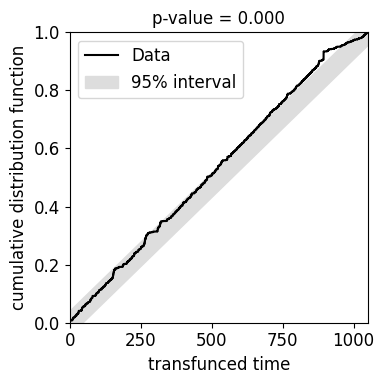

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


Asistencia animales compañia y otros


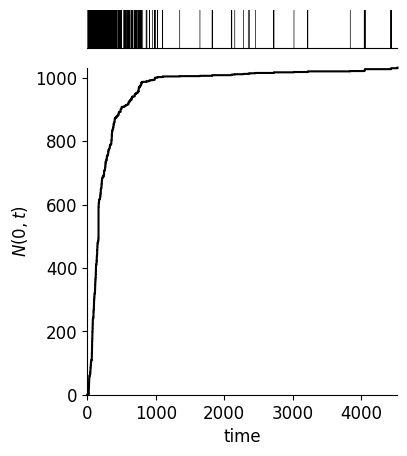

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


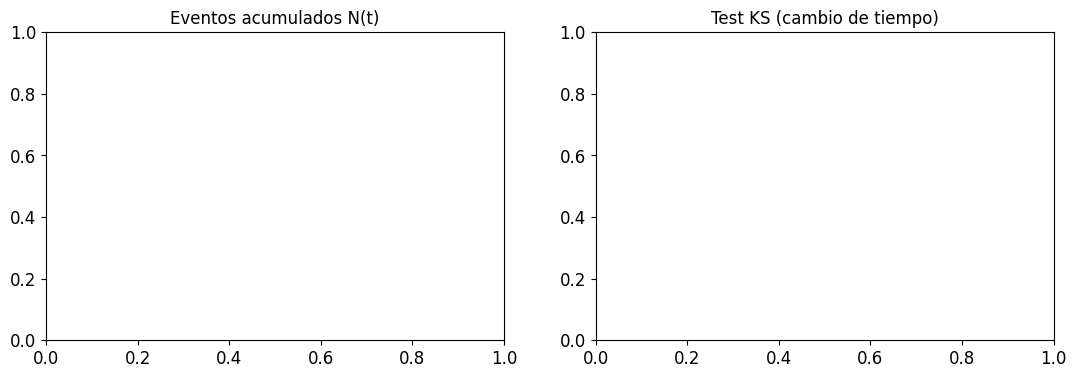

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


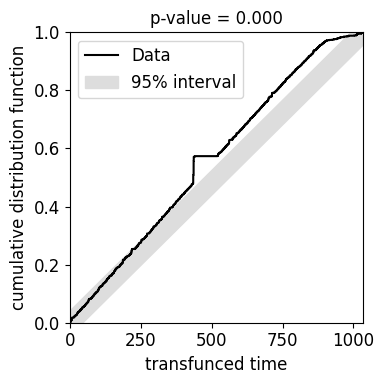

In [9]:
if HK_OK:
    for c in canales:
        print("="*80)
        print(c)
        m = modelos_hk[c]
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        plt.sca(axes[0]); m.plot_N();  axes[0].set_title("Eventos acumulados N(t)")
        plt.sca(axes[1]); m.plot_KS(); axes[1].set_title("Test KS (cambio de tiempo)")
        plt.tight_layout(); plt.show()
else:
    print("Paquete Hawkes no disponible; se omiten los diagnósticos.")

## 8. Comparación entre canales

Visualizamos los parámetros estimados (sección 4) para ver, como en el paper,
cómo varían entre canales.

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


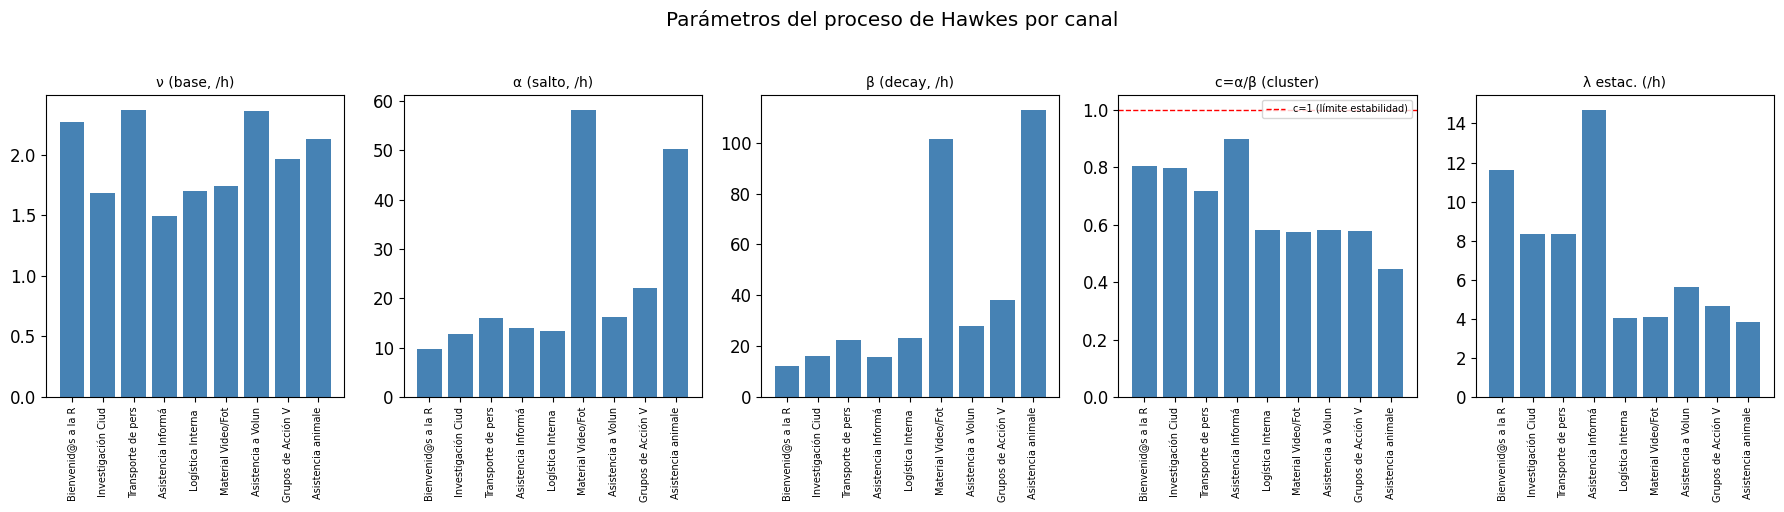

In [10]:
params_plot = tabla[["ν (base, /h)", "α (salto, /h)", "β (decay, /h)",
                     "c=α/β (cluster)", "λ estac. (/h)"]].astype(float)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
etiquetas = [c[:18] for c in params_plot.index]
for ax, col in zip(axes, params_plot.columns):
    ax.bar(range(len(params_plot)), params_plot[col].values, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xticks(range(len(params_plot)))
    ax.set_xticklabels(etiquetas, rotation=90, fontsize=7)
axes[3].axhline(1.0, color="red", ls="--", lw=1, label="c=1 (límite estabilidad)")
axes[3].legend(fontsize=7)
plt.suptitle("Parámetros del proceso de Hawkes por canal", y=1.02)
plt.tight_layout(); plt.show()

Intensidad estimada λ(t) para: Bienvenid@s a la Red de Voluntari@s (leed primero)


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


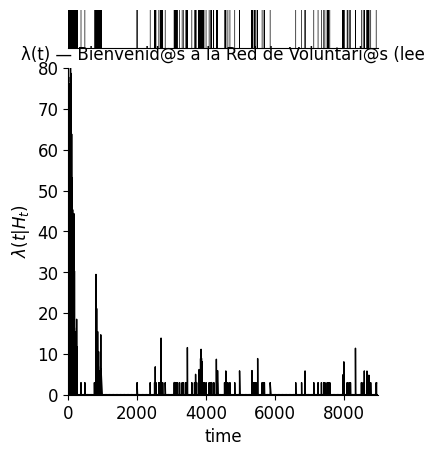

In [11]:
# Intensidad ajustada λ(t) de un canal (visualiza la auto-excitación a ráfagas)
if HK_OK:
    c0 = canales[0]
    print("Intensidad estimada λ(t) para:", c0)
    modelos_hk[c0].plot_l(); plt.title(f"λ(t) — {c0[:40]}"); plt.show()

## 9. Conclusiones

- Hemos ajustado un **proceso de Hawkes con kernel exponencial** a cada canal del grupo,
  por **máxima verosimilitud sobre días válidos**, replicando la metodología de Masuda et al. (2012).
- Para cada canal obtenemos $(\nu,\alpha,\beta)$ y las cantidades derivadas (branching ratio $c=\alpha/\beta$,
  tasa estacionaria). El **branching ratio** mide cuánta de la actividad es auto-excitada
  (reacciones en cadena) frente a espontánea ($\nu$).
- Los **CV > 1** confirman el carácter a ráfagas de la conversación, como en el paper.
- El **test KS** indica el grado de ajuste; igual que señala el paper, el Hawkes con kernel
  exponencial es un modelo simple y puede no capturar toda la estructura de correlación de los IET.

**Limitaciones (señaladas en el paper):** el modelo no puede modular de forma independiente
la correlación de los IET y el carácter a ráfagas, y no incluye modulación circadiana
(la actividad real tiene ciclos diarios). Una extensión natural sería usar una `baseline`
no constante del paquete (`loglinear`/`plinear`) para capturar el ciclo diario.
